Vary normalised distance with other parameters. Get 50 best parameters with different seeds. Slelect median and plot for those values.

In [1]:
import pandas as pd #For data frames. Just like excel
import numpy as np # For numerical computation . Like matlab
import sys # system functions
seasonal_df = pd.read_excel('Indigenous_input_R1.xlsx',index_col=0) # Pandas read function. Input is the file name and output starts from column 0.
#After running this, go to varibles {x} and check the dataframe "seasonal_df" has created or not.
#seasonal_df # Show the spreadsheet varibles. As in a table or plots.Check in case.
# seasonal_df.plot() # To plot the varibles in the dataframe

In [2]:
#calculate env flow released through the canal. There are 3 main canals. Inflow (div+rainfall) fraction is released.
seasonal_df['Inflow'] = seasonal_df['Diversion'] + seasonal_df['Catchment_inflow']  # Total inflow
seasonal_df['Inflow_check'] = seasonal_df['Diversion_check'] + seasonal_df['Catchment_inflow_check']


In [3]:
# Calculate crop water requirement
initial_days = 20
development_days = 30
middle_days = 30
late_days = 25

initial_kc = 1.0
development_kc = 1.15
middle_kc = 1.2
late_kc = 0.9

initial_cwr = seasonal_df['Ref_evapotranspiration_avg'] * initial_kc * initial_days / 30
development_cwr = seasonal_df['Ref_evapotranspiration_avg'] * development_kc * development_days / 30
middle_cwr = seasonal_df['Ref_evapotranspiration_avg'] * middle_kc * middle_days / 30
late_cwr = seasonal_df['Ref_evapotranspiration_avg'] * late_kc * late_days / 30

total_cwr = initial_cwr + development_cwr + middle_cwr + late_cwr
seasonal_df['Total_water_recquiremnt'] = total_cwr  # mm

In [4]:
import numpy as np

def reservoir_simulation(df, application_efficiency, initial_storage, storage_capacity, hedging_slope,
                         curve_steepness_storage, threshold_storage, land_preparation_wet,land_preparation_dry, eflow_river_factor, eflow_canal_factor_wet, eflow_canal_factor_dry,
                         curve_steepness_precipitation, threshold_precipitation, normalised_distance, pond_surface_area,max_pond_storage, pond_storage_factor
                         ):

    inflow = df['Inflow'].to_numpy()
    inflow_check = df['Inflow_check'].to_numpy()
    allocation = df['Allocation'].to_numpy()
    precipitation_check = df['Precipitation_check'].to_numpy() # Mar-July, Sep-Jan cumulative rainfall decides the season dry or wet
    precipitation_seasonal = df['Precipitation_seasonal'].to_numpy()
    total_cwr = df['Total_water_recquiremnt'].to_numpy()
    season = df['Season'].to_numpy()  # Get the season information
    spillage = df['Spillage'].to_numpy()

    N = len(inflow)

    storage = np.zeros(N)
    eflow_river = np.zeros(N)
    eflow_canal = np.zeros(N)
    withdrawal_irrigation = np.zeros(N)
    withdrawal_env = np.zeros(N)
    withdrawal = np.zeros(N)
    spill = np.zeros(N)
    deficit = np.zeros(N)
    available_water = np.zeros(N)
    effective_precipitation = np.zeros(N)
    total_wr = np.zeros(N)
    salience_storage = np.zeros(N)
    salience_precipitation = np.zeros(N)
    salience = np.zeros(N)
    #reliability = np.zeros(N)
    #dr_dt = np.zeros(N)
    cultivation_area = np.zeros(N)
    flexibility = np.zeros(N)
    irrigation_water_requirement = np.zeros(N)
    irrigation_water_demand = np.zeros(N)
    demand = np.zeros(N)
    water_duty = np.zeros(N)
    virtual_storage = np.zeros(N)
    combined_effect = np.zeros(N)
    pond_storage = np.zeros(N)
    available_pond_water = np.zeros(N)

    storage[0] = initial_storage
    #reliability[0] = initial_reliability

    for i in range(N):

        # Calculate virtual storage which represents seasonal storage
        virtual_storage[i] = storage[i] + inflow_check[i]

        # salience based on seasonal storage
        salience_storage[i] = 1 / (1 + np.exp(-curve_steepness_storage * (virtual_storage[i] - threshold_storage)))

        # salience based on rainfall
        salience_precipitation[i] = 1 / (1 + np.exp(-curve_steepness_precipitation * (precipitation_check[i] - threshold_precipitation)))

        # Combined salience
        salience[i] = salience_storage[i] * salience_precipitation[i]

        # Calculate pond storage
        pond_storage[i] = precipitation_seasonal[i] * pond_surface_area * pond_storage_factor * 0.001 * 1e-6 # mcm

        #Calculate flexibility generated by ponds
        flexibility[i] = np.clip(pond_storage[i] / max_pond_storage, 0, 1) * (1-normalised_distance)

        #Combined salience + flexibility effect
        combined_effect[i] = salience[i] + (1- salience[i]) * flexibility[i]

        # Calculate cultivation area
        command_area = 4721 # ha
        cultivation_area[i] = combined_effect[i] * command_area

        # Estimate water from ponds to satisfy CWR
        available_pond_water[i] = pond_storage[i] # mcm

        # Assign loss_factor and eflow_canal_factor based on the season
        if season[i] == 'Wet':
            land_preparation = land_preparation_wet
            loss_factor = 1.3
            eflow_canal_factor = eflow_canal_factor_wet
        else:
            land_preparation = land_preparation_dry
            loss_factor = 1.3  # Dry season value (can be changed if different)
            eflow_canal_factor = eflow_canal_factor_dry

        total_wr[i] = cultivation_area[i] * 10000 * 1e-9 *(total_cwr[i] + land_preparation) / application_efficiency
        effective_precipitation[i] = max(0, (precipitation_seasonal[i] - 150) * 0.67)

        irrigation_water_requirement[i] = max(0, total_wr[i] - (effective_precipitation[i] * cultivation_area[i] * 10000 * 0.001 * 1e-6 + available_pond_water[i]))

        irrigation_water_demand[i] = irrigation_water_requirement[i] * loss_factor # Account for conveynace loss
        #demand[i] = irrigation_water_demand[i] + eflow_canal[i]
        eflow_river[i] = inflow[i] * eflow_river_factor

        available_water[i] = storage[i] + inflow[i] - eflow_river[i] - allocation[i] - spillage[i]

        if available_water[i] < irrigation_water_demand[i] * hedging_slope:
            withdrawal_irrigation[i] = available_water[i] / hedging_slope
            withdrawal_env[i] = 0
        else:
            withdrawal_irrigation[i] = irrigation_water_demand[i]
            remaining_water = available_water[i] - irrigation_water_demand[i]

            eflow_canal[i] = remaining_water * eflow_canal_factor

            withdrawal_env[i] = eflow_canal[i]

        withdrawal[i] = withdrawal_irrigation[i] + withdrawal_env[i]
        trial_storage = available_water[i] - withdrawal[i]

        if trial_storage > storage_capacity:
            spill[i] = trial_storage - storage_capacity
            if i < N-1:
                storage[i+1] = storage_capacity
        else:
            spill[i] = 0
            if i < N-1:
                storage[i+1] = trial_storage

        deficit[i] = irrigation_water_demand[i] - withdrawal_irrigation[i]
       # water_duty[i] = withdrawal[i] * 100 / cultivation_area[i]

       # if i < N-1:
            #if i >= 1:
                #reliability[i+1] = 1 + reliability_decay_rate * (withdrawal_irrigation[i-1] - irrigation_water_demand[i-1]) / irrigation_water_demand[i-1]
            #else:
                #reliability[i+1] = initial_reliability

    df['Storage'] = storage
    df['Available_water'] = available_water
    #df['Reliability'] = reliability
    df['Cultivation_area'] = cultivation_area
    #df['Demand'] = demand
    df['Withdrawal'] = withdrawal
    df['Spill'] = spill
    df['Deficit'] = deficit
    df['Withdrawal_irrigation'] = withdrawal_irrigation
    df['Irrigation_demand'] = irrigation_water_demand
    df['Withdrawal_env'] = withdrawal_env
    df['Water_duty'] = water_duty  # Save water duty to the dataframe
    df['Flexibility'] = flexibility
    df['Salience'] = salience
    df['Combined_effect'] = combined_effect
    df['Virtual_storage'] = virtual_storage
    df['Pond_storage'] = pond_storage
    df['Available_pond_water'] = available_pond_water
    df['total_wr'] = total_wr
    df['effective_precipitation'] = effective_precipitation
    df['irrigation_water_requirement'] = irrigation_water_requirement
    df['irrigation_water_demand'] = irrigation_water_demand

    return df


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Best Parameter Set and Score for Each Seed:
    application_efficiency  hedging_slope  curve_steepness_storage  \
0                 0.553469       3.001851                 0.245579   
1                 0.553581       2.998278                 0.246079   
2                 0.553380       3.004032                 0.245486   
3                 0.552444       3.002928                 0.248474   
4                 0.552516       2.999247                 0.247783   
5                 0.552859       3.003770                 0.247418   
6                 0.553958       2.998217                 0.245275   
7                 0.554364       2.996498                 0.243872   
8                 0.554390       3.001589                 0.243399   
9                 0.524975       3.030833                 0.241722   
10                0.551750       3.001755                 0.249599   
11                0.500000       3.032707                 0.241042   
12                0.552512       3.004404     

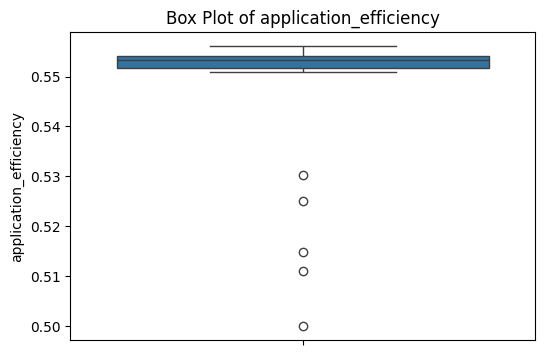

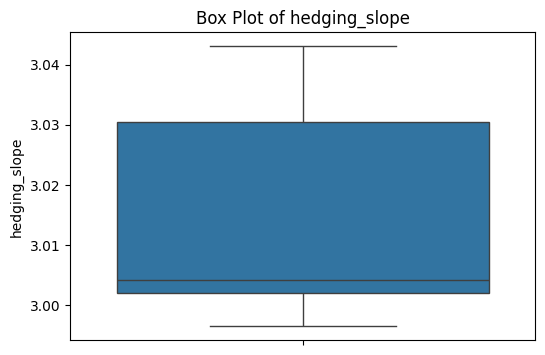

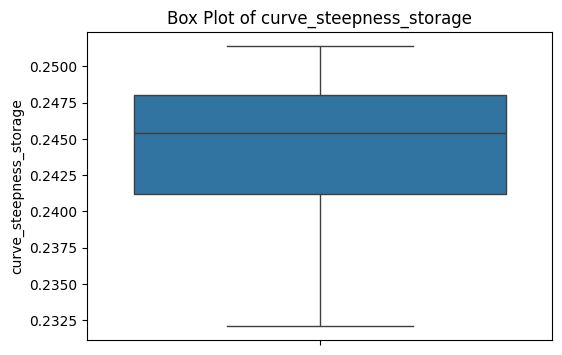

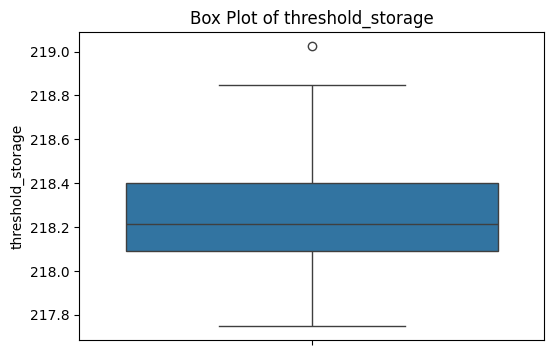

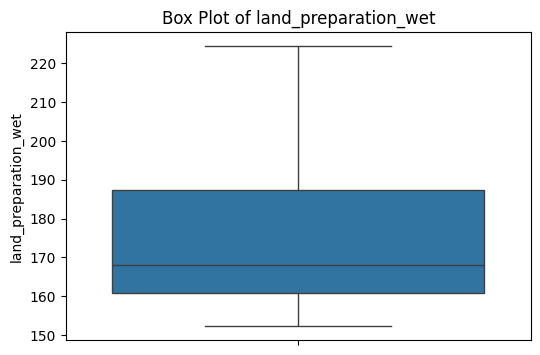

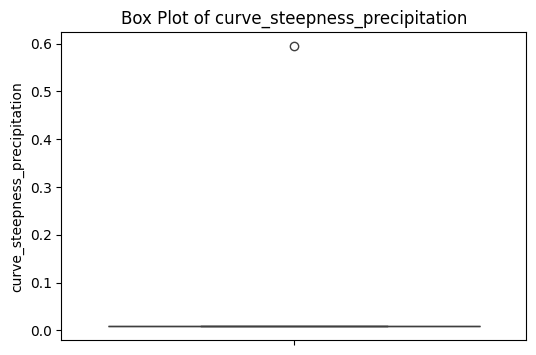

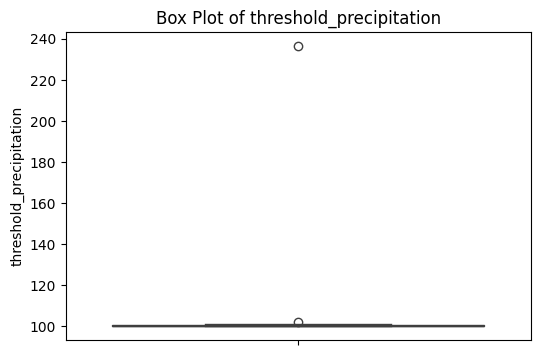

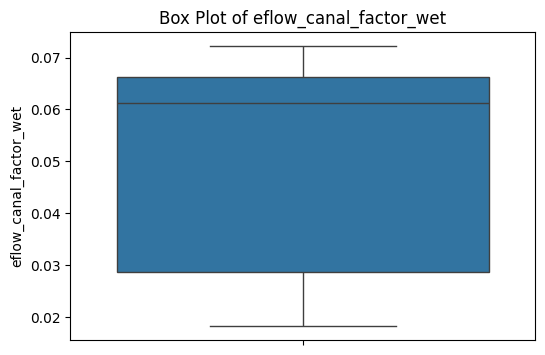

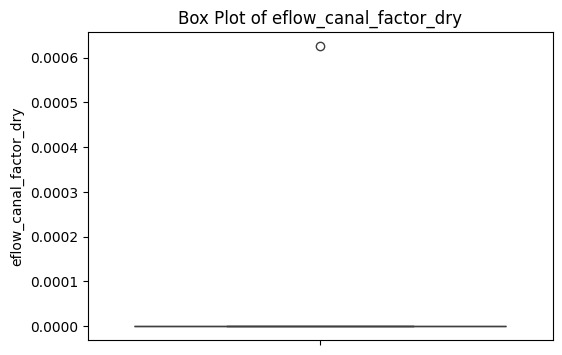

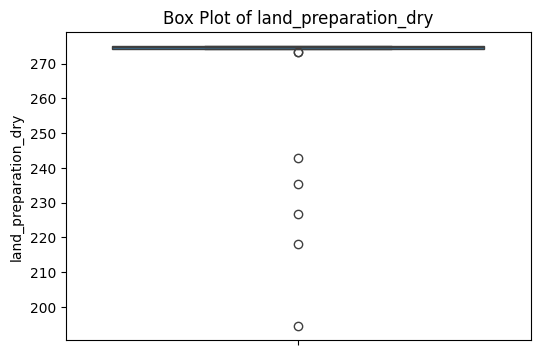

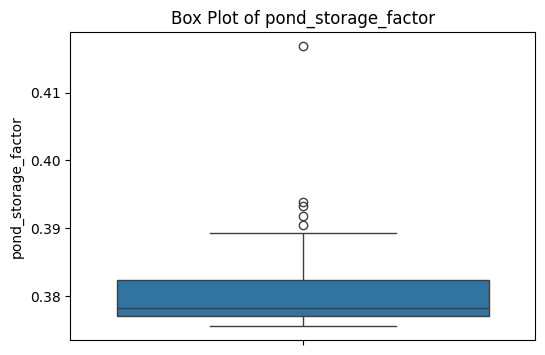

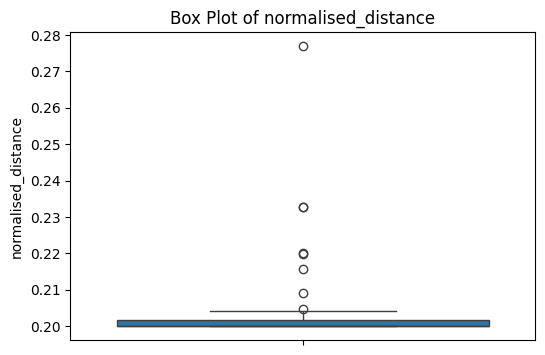

Representative Parameters:
application_efficiency: 0.5533497049372322
hedging_slope: 3.004182032432873
curve_steepness_storage: 0.24543661093784047
threshold_storage: 218.21247267190716
land_preparation_wet: 168.14074644624867
curve_steepness_precipitation: 0.00895509173631625
threshold_precipitation: 100.22045043056755
eflow_canal_factor_wet: 0.0613053721765823
eflow_canal_factor_dry: 0.0
land_preparation_dry: 274.7377236439321
pond_storage_factor: 0.37824329287523933
normalised_distance: 0.2
Optimized NSE (Cultivation Area): 0.7282827557851431


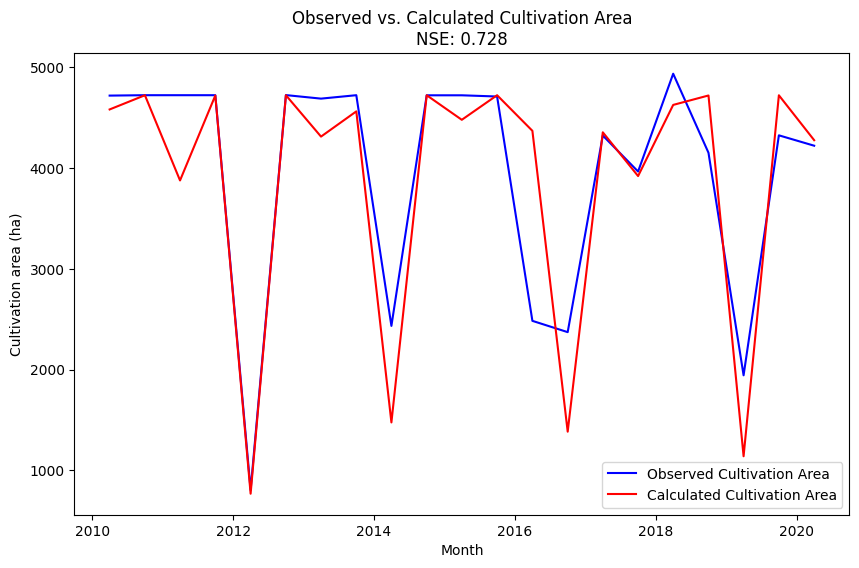

Optimized NSE (Withdrawal): 0.1744110065691643


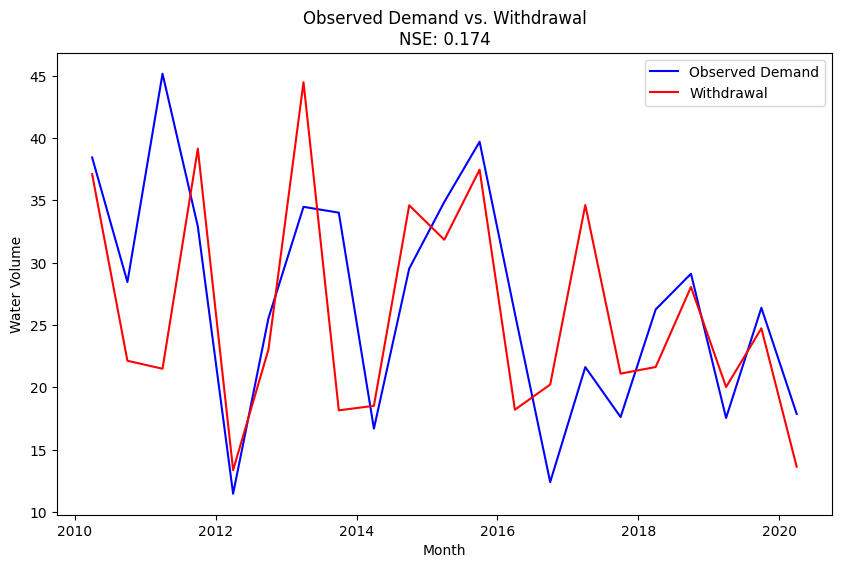

Optimized NSE (Storage): 0.8514060131218893


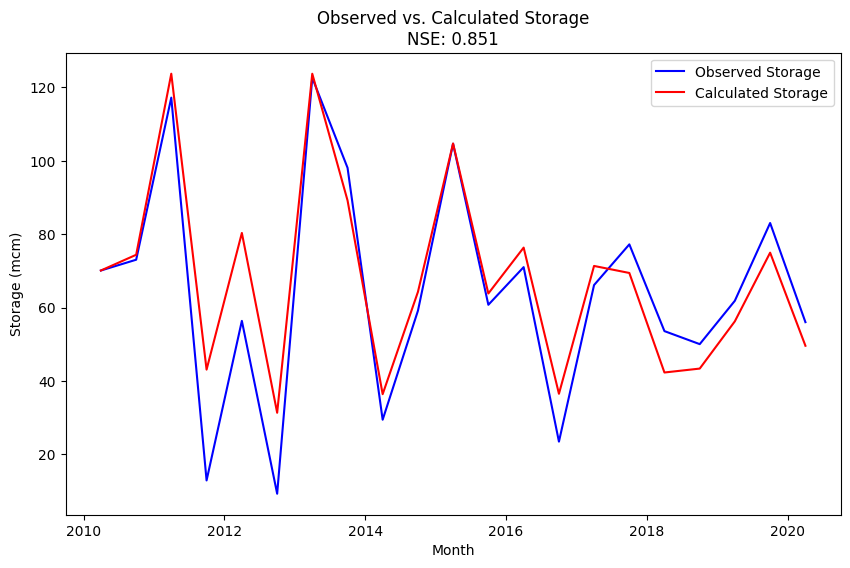

In [ ]:
import pandas as pd
import numpy as np
import sys
from scipy.optimize import dual_annealing # Import dual_annealing from scipy.optimize
import matplotlib.pyplot as plt # Import matplotlib for plotting

# Define the fixed parameters
fixed_params = {
    'initial_storage': 70.09,
    'storage_capacity': 123.7,
    'eflow_river_factor': 0,
    'pond_surface_area': 10.64e6,  # Fixed pond surface area in m²
    'max_pond_storage': 6.0  # Fixed max pond storage (example value, adjust as needed)
    #'normalised_distance': 0.2  # Fixed value for normalised_distance
}

# Define the parameter names and bounds for the parameters to be optimized
optimized_params_info = [
    ('application_efficiency', (0.5, 0.8)),
    ('hedging_slope', (1.0, 4.0)),
    ('curve_steepness_storage', (0.0, 1.0)),
    ('threshold_storage', (200, 500)),
    ('land_preparation_wet', (150, 275)),
    ('curve_steepness_precipitation', (0.0, 1)),
    ('threshold_precipitation', (100, 500)),
    ('eflow_canal_factor_wet', (0.0, 1.0)),
    ('eflow_canal_factor_dry', (0.0, 1.0)),
    ('land_preparation_dry', (150, 275)),
    ('pond_storage_factor', (0.0, 1.0)),  # Variable factor
    ('normalised_distance', (0.2, 1.0))

]

# Lists to store best parameter sets and scores for each seed
best_parameter_sets = []  # List to store best parameter sets
best_scores = []  # List to store corresponding scores
all_seeds = []  # List to store the seed used for each run
nse_cultivation_area_list = []  # List to store NSE for cultivation area
nse_withdrawal_list = []  # List to store NSE for withdrawal
nse_storage_list = []  # List to store NSE for storage

# Define the objective function for Simulated Annealing
def objective_function_sa(opt_params):
    # Combine fixed parameters with optimized parameters
    params = {
        'application_efficiency': opt_params[0],
        'hedging_slope': opt_params[1],
        'initial_storage': fixed_params['initial_storage'],  # Fixed parameter
        'storage_capacity': fixed_params['storage_capacity'],  # Fixed parameter
        'curve_steepness_storage': opt_params[2],
        'threshold_storage': opt_params[3],
        'land_preparation_wet': opt_params[4],
        'curve_steepness_precipitation': opt_params[5],
        'threshold_precipitation': opt_params[6],
        'eflow_canal_factor_wet': opt_params[7],
        'eflow_river_factor': fixed_params['eflow_river_factor'],  # Fixed parameter
        'eflow_canal_factor_dry': opt_params[8],
        'land_preparation_dry': opt_params[9],
        'pond_surface_area': fixed_params['pond_surface_area'],  # Fixed parameter
        'max_pond_storage': fixed_params['max_pond_storage'],  # Fixed parameter
        'pond_storage_factor': opt_params[10],
        'normalised_distance': opt_params[11]
    }

    simulated_df = reservoir_simulation(seasonal_df.copy(), **params)

    observed_cultivation_area = seasonal_df['Observed_cultivation_area'].to_numpy()
    simulated_cultivation_area = simulated_df['Cultivation_area'].to_numpy()

    observed_withdrawal = seasonal_df['Observed_demand'].to_numpy()
    simulated_withdrawal = simulated_df['Withdrawal'].to_numpy()

    observed_storage = seasonal_df['Observed_storage'].to_numpy()
    simulated_storage = simulated_df['Storage'].to_numpy()

    # Calculate the NSEs
    nse_cultivation_area = 1 - (np.sum((observed_cultivation_area - simulated_cultivation_area)**2) / np.sum((observed_cultivation_area - np.mean(observed_cultivation_area))**2))
    nse_withdrawal = 1 - (np.sum((observed_withdrawal - simulated_withdrawal)**2) / np.sum((observed_withdrawal - np.mean(observed_withdrawal))**2))
    nse_storage = 1 - (np.sum((observed_storage - simulated_storage)**2) / np.sum((observed_storage - np.mean(observed_storage))**2))

    # Combine the NSEs
    combined_nse = -(nse_cultivation_area + nse_withdrawal + nse_storage) / 3

    # Return the negative combined NSE to maximize it
    return combined_nse

# Extract the bounds for optimization
bounds = [bound for _, bound in optimized_params_info]

# Run optimization with multiple seeds
num_runs = 50  # Number of runs
for i in range(num_runs):
    seed = i * 5  # Different seed for each run
    np.random.seed(seed)
    result = dual_annealing(objective_function_sa, bounds, maxiter=1000)

    # Extract optimized parameters and the best score
    optimized_params = result.x
    #best_score = -result.fun  # Remember to negate since we minimized the negative NSE

    # Combine fixed parameters with optimized parameters for the final simulation
    final_params = {
        'application_efficiency': optimized_params[0],
        'hedging_slope': optimized_params[1],
        'initial_storage': fixed_params['initial_storage'],  # Fixed parameter
        'storage_capacity': fixed_params['storage_capacity'],  # Fixed parameter
        'curve_steepness_storage': optimized_params[2],
        'threshold_storage': optimized_params[3],
        'land_preparation_wet': optimized_params[4],
        'curve_steepness_precipitation': optimized_params[5],
        'threshold_precipitation': optimized_params[6],
        'eflow_canal_factor_wet': optimized_params[7],
        'eflow_river_factor': fixed_params['eflow_river_factor'],  # Fixed parameter
        'eflow_canal_factor_dry': optimized_params[8],
        'land_preparation_dry': optimized_params[9],
        'pond_surface_area': fixed_params['pond_surface_area'],  # Fixed parameter
        'max_pond_storage': fixed_params['max_pond_storage'],  # Fixed parameter
        'pond_storage_factor': optimized_params[10],
        'normalised_distance': optimized_params[11]
    }

    # Run simulation with optimized parameters
    optimized_df = reservoir_simulation(seasonal_df.copy(), **final_params)

    # Calculate NSE for cultivation area
    observed_cultivation_area = seasonal_df['Observed_cultivation_area'].to_numpy()
    optimized_cultivation_area = optimized_df['Cultivation_area'].to_numpy()
    nse_cultivation_area = 1 - (np.sum((observed_cultivation_area - optimized_cultivation_area)**2) / np.sum((observed_cultivation_area - np.mean(observed_cultivation_area))**2))

    # Calculate NSE for observed demand vs. withdrawal
    observed_withdrawal = seasonal_df['Observed_demand'].to_numpy()
    optimized_withdrawal = optimized_df['Withdrawal'].to_numpy()
    nse_withdrawal = 1 - (np.sum((observed_withdrawal - optimized_withdrawal)**2) / np.sum((observed_withdrawal - np.mean(observed_withdrawal))**2))

    # Calculate NSE for observed and simulated storage
    observed_storage = seasonal_df['Observed_storage'].to_numpy()
    optimized_storage = optimized_df['Storage'].to_numpy()
    nse_storage = 1 - (np.sum((observed_storage - optimized_storage)**2) / np.sum((observed_storage - np.mean(observed_storage))**2))

    # Store results for this seed
    best_parameter_sets.append(result.x)  # Store best parameter set
    best_scores.append(-result.fun)  # Store the best score
    all_seeds.append(seed)  # Store the seed

    # Store NSE values
    nse_cultivation_area_list.append(nse_cultivation_area)
    nse_withdrawal_list.append(nse_withdrawal)
    nse_storage_list.append(nse_storage)

# Create DataFrame for best parameter sets
param_names = [name for name, _ in optimized_params_info]  # Get parameter names
results_df = pd.DataFrame(best_parameter_sets, columns=param_names)
results_df['Score'] = best_scores  # Add the scores column
results_df['Seed'] = all_seeds  # Add the seed column
results_df['NSE_Cultivation_Area'] = nse_cultivation_area_list  # Add NSE for cultivation area
results_df['NSE_Withdrawal'] = nse_withdrawal_list  # Add NSE for withdrawal
results_df['NSE_Storage'] = nse_storage_list  # Add NSE for storage

# Output the results DataFrame
print("Best Parameter Set and Score for Each Seed:")
print(results_df)

# Save to Excel (optional)
results_df.to_excel('YE_Feb_08.xlsx', index=False)

results_df.to_excel('/content/drive/MyDrive/Colab_Notebooks/YE_Feb_08.xlsx', index=False)

import matplotlib.pyplot as plt
import seaborn as sns  # Import seaborn for better box plot aesthetics

for param in param_names:
    plt.figure(figsize=(6, 4))  # Adjust figure size as needed
    sns.boxplot(y=results_df[param])  # Use 'y' to plot vertically
    plt.title(f'Box Plot of {param}')
    plt.ylabel(param)  # Label the y-axis with the parameter name
    plt.show()

representative_params = {}
for param in param_names:
    # Choose the preferred representative value (e.g., median)
    representative_params[param] = results_df[param].median()  # Or .mean() or a value within IQR

# Print representative parameters
print("Representative Parameters:")
for param, value in representative_params.items():
    print(f"{param}: {value}")
# Combine fixed parameters with representative parameters
final_params = {**fixed_params, **representative_params}

# Run the simulation with representative parameters
optimized_df = reservoir_simulation(seasonal_df.copy(), **final_params)

# Calculate NSE for cultivation area
observed_cultivation_area = seasonal_df['Observed_cultivation_area'].to_numpy()
optimized_cultivation_area = optimized_df['Cultivation_area'].to_numpy()
nse_cultivation_area = 1 - (np.sum((observed_cultivation_area - optimized_cultivation_area)**2) / np.sum((observed_cultivation_area - np.mean(observed_cultivation_area))**2))
print(f'Optimized NSE (Cultivation Area): {nse_cultivation_area}')

# Plot the observed and calculated cultivation areas
plt.figure(figsize=(10, 6))
plt.plot(seasonal_df.index, observed_cultivation_area, label='Observed Cultivation Area', color='blue')
plt.plot(seasonal_df.index, optimized_cultivation_area, label='Calculated Cultivation Area', color='red')
plt.xlabel('Month')
plt.ylabel('Cultivation area (ha)')
plt.legend()
plt.title(f'Observed vs. Calculated Cultivation Area\nNSE: {nse_cultivation_area:.3f}')
plt.show()

# Calculate NSE for observed demand vs. withdrawal
observed_withdrawal = seasonal_df['Observed_demand'].to_numpy()
optimized_withdrawal = optimized_df['Withdrawal'].to_numpy()
nse_withdrawal = 1 - (np.sum((observed_withdrawal - optimized_withdrawal)**2) / np.sum((observed_withdrawal - np.mean(observed_withdrawal))**2))
print(f'Optimized NSE (Withdrawal): {nse_withdrawal}')

# Plot the observed demand vs. withdrawal
plt.figure(figsize=(10, 6))
plt.plot(seasonal_df.index, observed_withdrawal, label='Observed Demand', color='blue')
plt.plot(seasonal_df.index, optimized_withdrawal, label='Withdrawal', color='red')
plt.xlabel('Month')
plt.ylabel('Water Volume')
plt.legend()
plt.title(f'Observed Demand vs. Withdrawal\nNSE: {nse_withdrawal:.3f}')
plt.show()

# Calculate NSE for observed and simulated storage
observed_storage = seasonal_df['Observed_storage'].to_numpy()
optimized_storage = optimized_df['Storage'].to_numpy()
nse_storage = 1 - (np.sum((observed_storage - optimized_storage)**2) / np.sum((observed_storage - np.mean(observed_storage))**2))
print(f'Optimized NSE (Storage): {nse_storage}')

# Plot the observed and calculated storage
plt.figure(figsize=(10, 6))
plt.plot(seasonal_df.index, observed_storage, label='Observed Storage', color='blue')
plt.plot(seasonal_df.index, optimized_storage, label='Calculated Storage', color='red')
plt.xlabel('Month')
plt.ylabel('Storage (mcm)')
plt.legend()
plt.title(f'Observed vs. Calculated Storage\nNSE: {nse_storage:.3f}')
plt.show()

